In [3]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

df = pd.read_csv('Relation Network (Directed).data',
                 sep=None, engine='python', header=None)

df = df.iloc[:, 1:]          # убираем столбец id
X = df.select_dtypes(include=[np.number])
X = X.sample(n=5000, random_state=42)

scaler = StandardScaler()    # масштабируем данные
X_scaled = scaler.fit_transform(X)

print("Исходная форма данных:")
print(X.head(1))
print("\nПосле масштабирования:")
print(X_scaled[:1])


Исходная форма данных:
       1   2   3   4   5   6    7     8   9   10  ...   14  15   16    17  \
38772   8   5   3   1   1   5  1.0  1.25   0   0  ...  0.0   0  0.0  1.25   

        18     19   20   21   22   23  
38772  0.0  0.625  0.5  0.5  0.5  0.0  

[1 rows x 23 columns]

После масштабирования:
[[-0.47703761 -0.49245817  0.95180266 -0.77483556 -0.02450225 -0.37837737
  -0.65239512 -0.77151907  0.          0.         -0.26249384 -0.81928351
  -0.78289939 -0.03331268  0.         -0.33940946 -0.78289939 -0.56211997
  -0.78289939 -0.51734905  0.27013741 -0.52630701 -0.97530813]]


Пропуски данных отсутствуют.

In [9]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
print("KMeans — количество кластеров:", len(set(kmeans_labels)))
print("KMeans — метрика силуэта:", silhouette_score(X_scaled, kmeans_labels))

# Agglomerative
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
print("Agglomerative — количество кластеров:", len(set(agg_labels)))
print("Agglomerative — метрика силуэта:", silhouette_score(X_scaled, agg_labels))

# DBSCAN
dbscan = DBSCAN(eps=3.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
print("DBSCAN — количество кластеров:", len(set(dbscan_labels)))
print("DBSCAN — метрика силуэта:", silhouette_score(X_scaled, dbscan_labels))

KMeans — количество кластеров: 3
KMeans — метрика силуэта: 0.25578738614908214
Agglomerative — количество кластеров: 3
Agglomerative — метрика силуэта: 0.48849240258219995
DBSCAN — количество кластеров: 4
DBSCAN — метрика силуэта: 0.5621325002355314


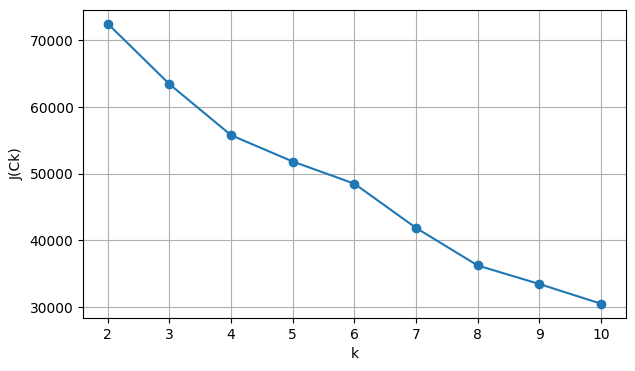

In [5]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


k_values = range(2, 11)
inertias = []


for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)   # J(Ck) — сумма квадратов расстояний


plt.figure(figsize=(7,4))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("J(Ck)")
plt.grid(True)
plt.show()


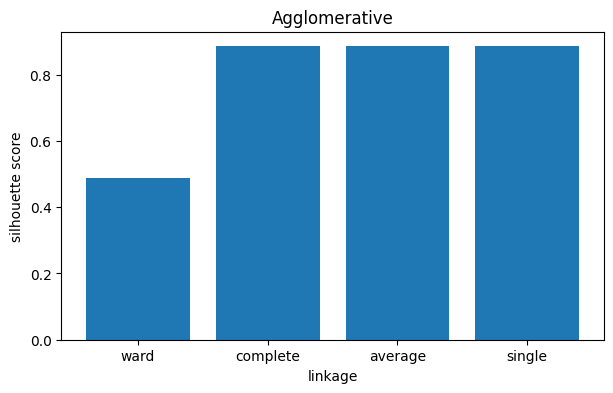

In [8]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

linkages = ["ward", "complete", "average", "single"]
scores = []

for link in linkages:
    model = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.figure(figsize=(7,4))
plt.bar(linkages, scores)
plt.xlabel("linkage")
plt.ylabel("silhouette score")
plt.title("Agglomerative")
plt.show()


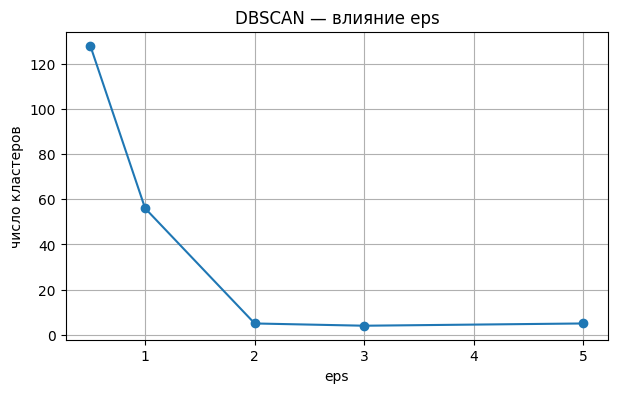

In [9]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

eps_values = [0.5, 1.0, 2.0, 3.0, 5.0]
cluster_counts = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_scaled)
    cluster_counts.append(len(set(labels)))

plt.figure(figsize=(7,4))
plt.plot(eps_values, cluster_counts, marker='o')
plt.xlabel("eps")
plt.ylabel("число кластеров")
plt.title("DBSCAN — влияние eps")
plt.grid(True)
plt.show()


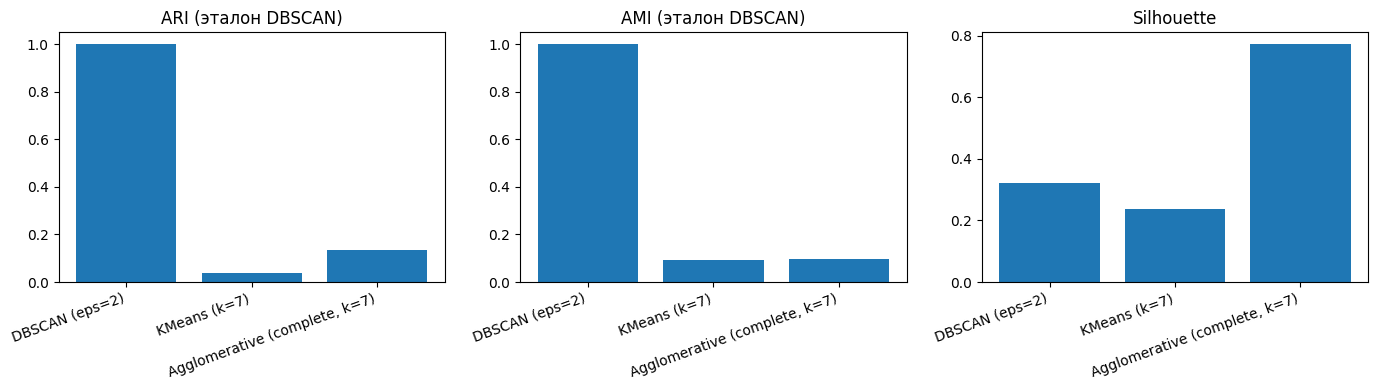

In [7]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score
import matplotlib.pyplot as plt

results = {}

# dbscan как эталон
dbscan = DBSCAN(eps=2.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

results["DBSCAN (eps=2)"] = {
    "silhouette": silhouette_score(X_scaled, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1,
    "ari": 1.0,
    "ami": 1.0
}

# kmeans с k=7
kmeans = KMeans(n_clusters=7, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

results["KMeans (k=7)"] = {
    "silhouette": silhouette_score(X_scaled, labels_kmeans),
    "ari": adjusted_rand_score(labels_dbscan, labels_kmeans),
    "ami": adjusted_mutual_info_score(labels_dbscan, labels_kmeans)
}

# agglomerative complete, k=7
agg = AgglomerativeClustering(n_clusters=7, linkage="single")
labels_agg = agg.fit_predict(X_scaled)

results["Agglomerative (complete, k=7)"] = {
    "silhouette": silhouette_score(X_scaled, labels_agg),
    "ari": adjusted_rand_score(labels_dbscan, labels_agg),
    "ami": adjusted_mutual_info_score(labels_dbscan, labels_agg)
}

# визуализация
labels = list(results.keys())
silh = [results[m]["silhouette"] for m in labels]
ari = [results[m]["ari"] for m in labels]
ami = [results[m]["ami"] for m in labels]

plt.figure(figsize=(14, 4))

plt.subplot(1,3,1)
plt.bar(labels, ari)
plt.title("ARI (эталон DBSCAN)")
plt.xticks(rotation=20, ha='right')

plt.subplot(1,3,2)
plt.bar(labels, ami)
plt.title("AMI")
plt.xticks(rotation=20, ha='right')

plt.subplot(1,3,3)
plt.bar(labels, silh)
plt.title("Silhouette")
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()
